## Librairies

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx

# Phase 1 - Préparer les données

## P1 - Charger et nettoyer les données

In [34]:
df = pd.read_csv("data\source\Clinique_MonVert_SourceDataset.csv")
df_copy = df.copy()

noise_phrases = ["Hi IT team", "The", "A", "I", "My", "Please", "I'm", "Our"]

def normalize_text(text):
    if not isinstance(text, str): return ""
    # 1. Clean punctuation first so "Hi, IT team" becomes "Hi IT team"
    text = text.replace('"', '')
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # 2. Build flexible pattern for the noise
    noise_pattern = '|'.join([re.escape(p).replace(r'\ ', r'\s+') for p in sorted(noise_phrases, key=len, reverse=True)])

    # 3. Remove noise and lowercase
    text = re.sub(r'(?i)\b(' + noise_pattern + r')\b', '', text)
    return re.sub(r'\s+', ' ', text).strip().lower()

df_copy['normalized_text'] = (df_copy['ticket_label'].fillna('') + " " + df_copy['ticket_description'].fillna('')).apply(normalize_text)

print(f"{len(df_copy)} tickets chargés — {df_copy['category'].nunique()} catégories détectées")
print()
print(df_copy['category'].value_counts().to_string())

1405 tickets chargés — 7 catégories détectées

category
Network     238
Security    235
Bug         214
Access      205
Error       177
Software    175
Support     161


<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\jbrae\AppData\Local\Temp\ipykernel_4240\3600894497.py:1: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("data\source\Clinique_MonVert_SourceDataset.csv")


## P2 - Générer des Intégrations (SBERT)

In [35]:
# SBERT convertit chaque ticket en un vecteur de 384 dimensions qui capture son sens.
# Deux tickets avec le même problème auront des vecteurs très proches, même formulés différemment.
model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(df_copy['normalized_text'].tolist(), show_progress_bar=True)

X = np.array(embeddings)

print(f"{X.shape[0]} tickets convertis en vecteurs de {X.shape[1]} dimensions")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 900.50it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 44/44 [00:05<00:00,  8.51it/s]

1405 tickets convertis en vecteurs de 384 dimensions


# Phase 2 - Visualisation et regroupement

## P1 - Visualisation T-SNE (Galaxy Plot)

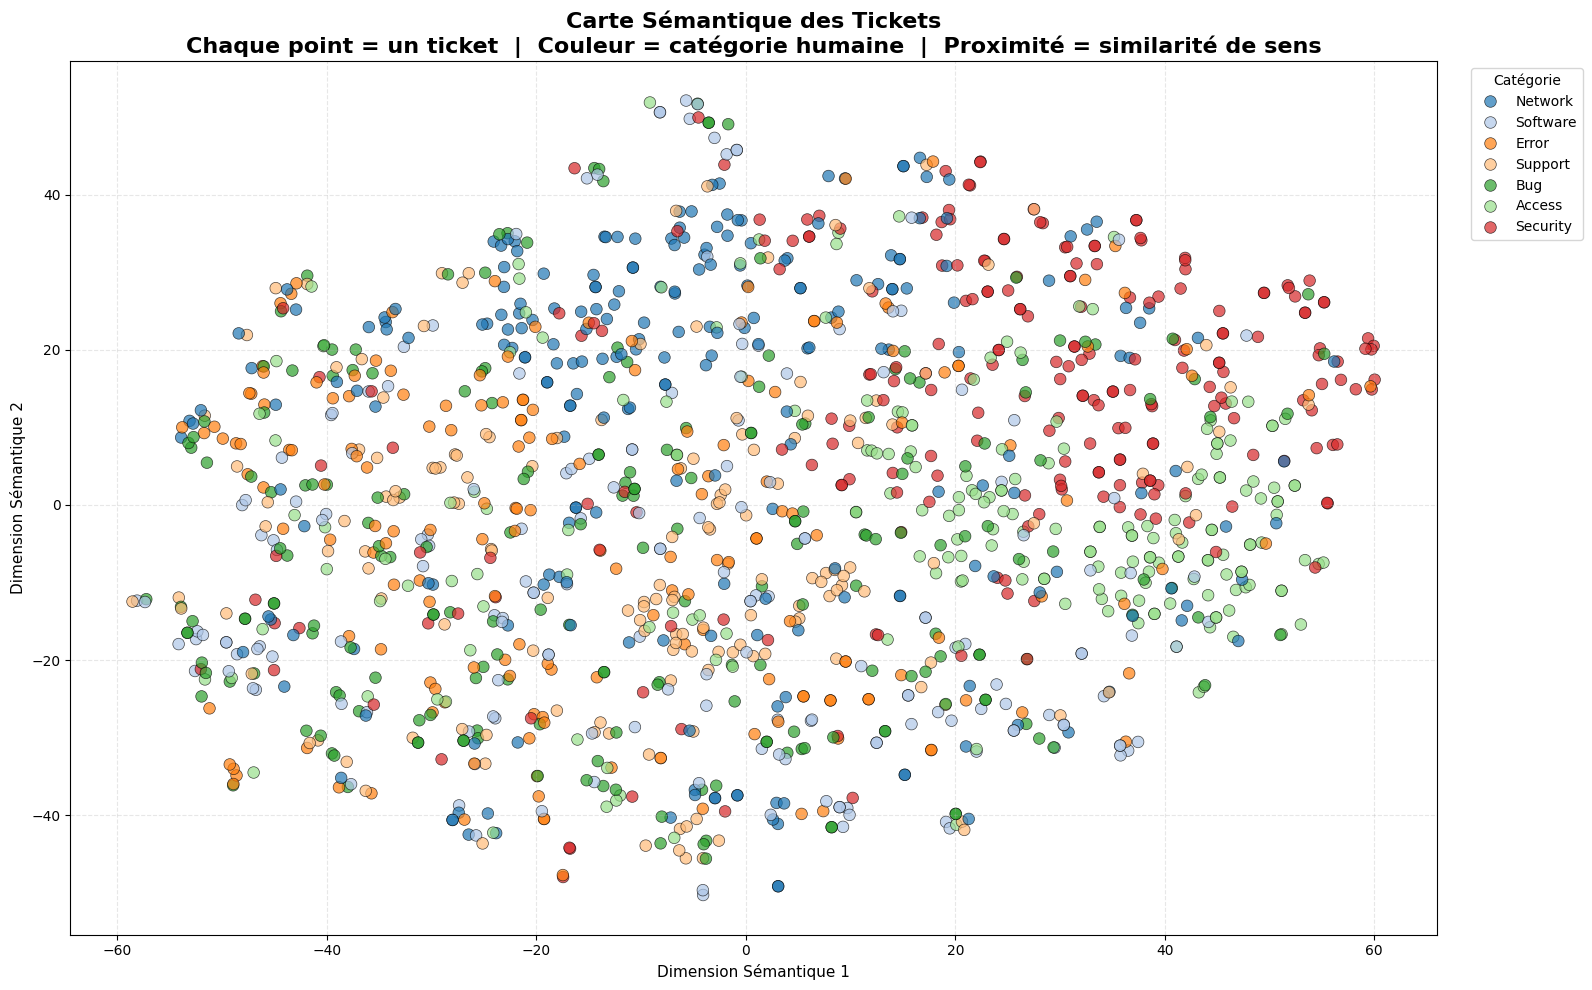

In [36]:
# T-SNE compresse les 384 dimensions en 2D pour la visualisation.
# Les tickets au sujet similaire apparaissent naturellement groupés sur la carte.
tsne = TSNE(n_components=2, perplexity=35, max_iter=1000,
            init='pca', learning_rate='auto', random_state=42, n_jobs=-1)

embeddings_2d  = tsne.fit_transform(X)
df_copy['x']   = embeddings_2d[:, 0]
df_copy['y']   = embeddings_2d[:, 1]

plt.figure(figsize=(16, 10))
ax = sns.scatterplot(x='x', y='y', hue='category', data=df_copy,
                     palette='tab20', s=70, alpha=0.7, edgecolor='black', linewidth=0.5)

plt.title("Carte Sémantique des Tickets\nChaque point = un ticket  |  Couleur = catégorie humaine  |  Proximité = similarité de sens",
          fontsize=16, weight='bold')
plt.xlabel("Dimension Sémantique 1", fontsize=11)
plt.ylabel("Dimension Sémantique 2", fontsize=11)

handles, labels = ax.get_legend_handles_labels()
ax.legend([h for h, l in zip(handles, labels) if l != 'category'],
          [l for l in labels if l != 'category'],
          title="Catégorie", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Phase 3 - Détection des tickets mal catégorisés et suggestion d'une nouvelle catégorie

## P1 - Audit

✅ 100 tickets mal catégorisés détectés sur 1405 (7.1%)


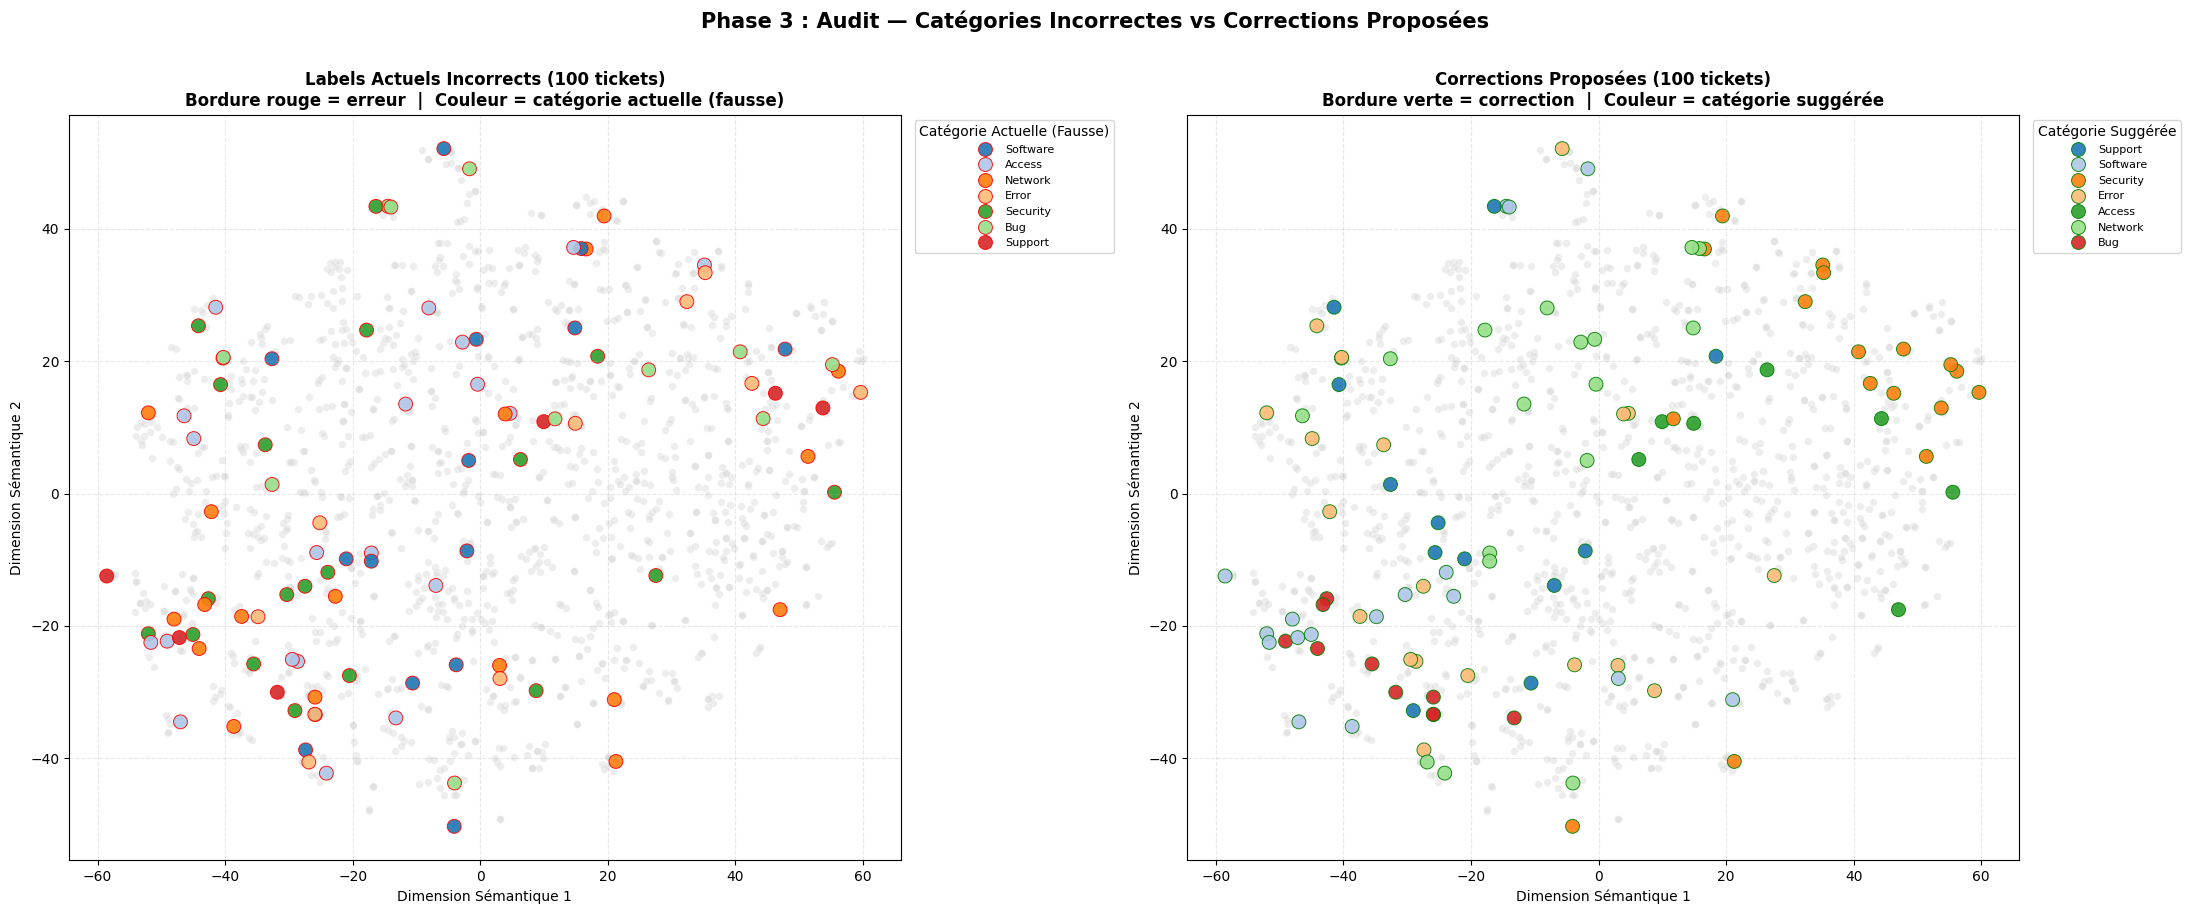

In [37]:
# Centre sémantique de chaque catégorie
category_centers = {}
for cat in df_copy['category'].unique():
    idx = df_copy[df_copy['category'] == cat].index
    category_centers[cat] = np.mean(X[idx], axis=0)

# Catégorie la plus proche pour chaque ticket
category_names  = list(category_centers.keys())
category_matrix = np.array([category_centers[c] for c in category_names])
all_sim         = cosine_similarity(X, category_matrix)

df_copy['ai_suggested_category'] = [category_names[i] for i in np.argmax(all_sim, axis=1)]
df_copy['suggested_similarity']  = np.max(all_sim, axis=1)

# Similarité avec la catégorie actuelle
df_copy['current_similarity'] = [
    cosine_similarity(X[i].reshape(1,-1),
                      category_centers[df_copy.iloc[i]['category']].reshape(1,-1))[0][0]
    for i in range(len(df_copy))
]

# Seuil dynamique — 10% des tickets les moins bien classés
threshold = df_copy['current_similarity'].quantile(0.08)

# Tickets mal catégorisés
error_df = df_copy[
    (df_copy['category'] != df_copy['ai_suggested_category']) &
    (df_copy['current_similarity'] < threshold)
]

print(f"✅ {len(error_df)} tickets mal catégorisés détectés sur {len(df_copy)} ({len(error_df)/len(df_copy)*100:.1f}%)")

# Graphiques
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

for ax, hue_col, edge_col, title, legend_title in [
    (axes[0], 'category',              'red',
     f"Labels Actuels Incorrects ({len(error_df)} tickets)\nBordure rouge = erreur  |  Couleur = catégorie actuelle (fausse)",
     'Catégorie Actuelle (Fausse)'),
    (axes[1], 'ai_suggested_category', 'green',
     f"Corrections Proposées ({len(error_df)} tickets)\nBordure verte = correction  |  Couleur = catégorie suggérée",
     'Catégorie Suggérée')
]:
    sns.scatterplot(x='x', y='y', data=df_copy,
                    color='lightgrey', s=30, alpha=0.4, ax=ax)
    sns.scatterplot(x='x', y='y', hue=hue_col, data=error_df,
                    palette='tab20', s=100, alpha=0.9,
                    edgecolor=edge_col, linewidth=0.7, ax=ax)
    ax.set_title(title, fontsize=12, weight='bold')
    ax.set_xlabel("Dimension Sémantique 1")
    ax.set_ylabel("Dimension Sémantique 2")
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left',
              title=legend_title, fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle("Phase 3 : Audit — Catégories Incorrectes vs Corrections Proposées",
             fontsize=15, weight='bold', y=1.01)
plt.tight_layout()
plt.show()

## P2 - Suggérer des catégories

In [38]:
# Tickets mal catégorisés triés par écart de similarité décroissant.
# Un similarity_gap élevé = l'erreur est évidente et la correction est fiable.
cols_to_show = ['ticket_id', 'ticket_description', 'category', 'ai_suggested_category', 'suggested_similarity', 'current_similarity']

if not error_df.empty:
    display(error_df[cols_to_show].sort_values('suggested_similarity', ascending=False))

,ticket_id,ticket_description,category,ai_suggested_category,suggested_similarity,current_similarity
1129,TIC-1530,Hello team. Staff are bypassing secure individ...,Network,Security,0.581734,0.348861
747,TIC-1148,"Hello IT, the decimal point is shifting incorr...",Network,Software,0.566627,0.320564
707,TIC-1108,"Greetings, someone posted our secure surgical ...",Error,Security,0.563832,0.297768
1157,TIC-1558,Hi IT. Anyone on the local network can browse ...,Error,Security,0.560716,0.319129
1193,TIC-1594,Greetings. The legacy medical application dema...,Network,Access,0.558526,0.347534
...,...,...,...,...,...,...
1097,TIC-1498,"Greetings, a tool struck the glass. We cannot ...",Network,Error,0.302331,0.244043
40,TIC-0441,The brainwave tracings are completely obscured...,Software,Support,0.289412,0.235535
1076,TIC-1477,"Hi IT, anyone can type the default pin and ope...",Support,Access,0.261640,0.236774
859,TIC-1260,"Dear IT, the rendering engine is reversing the...",Support,Software,0.245975,0.231955


# Phase 4 Détection des tickets doublons et similaire

In [45]:
# Construction du graphe de relations basé sur la similarité
adj_matrix = (cosine_similarity(embeddings) > 0.84).astype(int)
np.fill_diagonal(adj_matrix, 0)
G = nx.from_numpy_array(adj_matrix)

# Initialisation du marquage pour la phase de priorisation
df_copy['is_redundant'] = False
incident_data = []

for cluster_id, indices in enumerate(nx.connected_components(G)):
    idx_list = list(indices)

    # On ne traite que les groupes contenant au moins deux tickets
    if len(idx_list) > 1:
        # On marque tous les tickets sauf le premier (le "Maître") comme redondants
        df_copy.loc[idx_list[1:], 'is_redundant'] = True

        master = df_copy.iloc[idx_list[0]]
        # On récupère la liste des IDs qui seront fermés
        redundant_ids = df_copy.iloc[idx_list[1:]]['ticket_id'].tolist()

        # Distinction entre doublon textuel et similarité sémantique
        is_exact = df_copy.iloc[idx_list]['ticket_description'].nunique() == 1

        incident_data.append({
            'Cluster_ID'   : cluster_id,
            'Total'        : len(idx_list),
            'Type'         : 'Doublon Exact' if is_exact else 'Similarité Sémantique',
            'Sujet'        : master['ticket_description'],
            'ID_Maître'    : master['ticket_id'],
            'IDs_Redondants': redundant_ids,  # Liste complète des tickets à fermer
        })

# Création du DataFrame de synthèse pour le rapport d'audit
df_incidents = pd.DataFrame(incident_data).sort_values('Total', ascending=False)

print(f"Analyse terminée : {len(df_incidents)} incidents multiples identifiés.")
display(df_incidents)
print("Total number of individual redundant tickets:", df_copy['is_redundant'].sum())

Analyse terminée : 158 incidents multiples identifiés.


,Cluster_ID,Total,Type,Sujet,ID_Maître,IDs_Redondants
13,189,8,Similarité Sémantique,"Hi team, the application maliciously changes u...",TIC-1492,"[TIC-1691, TIC-1183, TIC-1791, TIC-1089, TIC-1..."
22,296,8,Similarité Sémantique,"Greetings, the rendering engine misaligns the ...",TIC-1298,"[TIC-1204, TIC-0697, TIC-1499, TIC-1564, TIC-1..."
1,52,5,Similarité Sémantique,"Hello team, the software changes pounds to kil...",TIC-1656,"[TIC-1756, TIC-1536, TIC-0453, TIC-1196]"
48,590,5,Similarité Sémantique,"Hello team, her account permissions were inexp...",TIC-1301,"[TIC-1000, TIC-1096, TIC-1705, TIC-1805]"
55,676,5,Similarité Sémantique,"Hello IT, the digital timezone logic is comple...",TIC-1801,"[TIC-1305, TIC-1501, TIC-1701, TIC-1097]"
...,...,...,...,...,...,...
153,1192,2,Doublon Exact,"Hi team, a firewall error exposed the digital ...",TIC-1793,[TIC-1693]
154,1193,2,Doublon Exact,"Good morning, the software logic is severely f...",TIC-1794,[TIC-1694]
155,1194,2,Doublon Exact,"Hi IT, the browser blocks access due to expire...",TIC-1698,[TIC-1798]
156,1195,2,Doublon Exact,"Good morning, the massive digital files timeou...",TIC-1699,[TIC-1799]


Total number of individual redundant tickets: 208


# Phase 5 - Prioriser les tickets

In [40]:
# 1. Configuration des poids par catégorie et des mots-clés critiques
PRIORITY_WEIGHTS = {
    'Security': 5000, 'Network': 1000, 'Access': 600, 'Backup': 400,
    'Bug': 300, 'Error': 200, 'Software': 150, 'Support': 100, 'General': 50
}
REAL_THREATS = ['phishing', 'malware', 'virus', 'compromised', 'hacked', 'breached']
URGENT_WORDS = ['urgent', 'critical', 'down']

def calculate_priority_final(row):
    # CRITIQUE : Si le ticket a été identifié comme doublon (Phase 4), son score est 0
    if row.get('is_redundant', False):
        return 0

    # ÉTAPE A : Déterminer la catégorie "effective" (Audit IA)
    is_error = (row['current_similarity'] < threshold) and (row['category'] != row['ai_suggested_category'])
    effective_cat = row['ai_suggested_category'] if is_error else row['category']

    # ÉTAPE B : Calcul du score de base
    score = PRIORITY_WEIGHTS.get(effective_cat, 50)
    text = str(row['normalized_text']).lower()

    # ÉTAPE C : Application des bonus d'urgence
    if any(t in text for t in REAL_THREATS): score += 2000
    if any(k in text for k in URGENT_WORDS): score += 500

    return score

# 2. Application et tri de la file d'attente
df_copy['final_priority_score'] = df_copy.apply(calculate_priority_final, axis=1)
df_final_prioritized = df_copy.sort_values(by='final_priority_score', ascending=False)

# 3. Affichage des 500 premiers tickets (Le "Smart Backlog")
print(f"✅ {len(df_final_prioritized)} tickets traités avec succès.")
display(df_final_prioritized[['ticket_id', 'ticket_description', 'category', 'ai_suggested_category', 'final_priority_score']].head(500))

✅ 1405 tickets traités avec succès.


,ticket_id,ticket_description,category,ai_suggested_category,final_priority_score
318,TIC-0719,The user entered their credentials into a fake...,Security,Security,7500
158,TIC-0559,"Instead of the hospital terms of service, visi...",Security,Security,7500
364,TIC-0765,Anyone can plug a flash drive into the patient...,Security,Security,7000
448,TIC-0849,A physician's account is actively sending out ...,Security,Security,7000
657,TIC-1058,Visitors attempting to accept the terms of ser...,Security,Security,7000
...,...,...,...,...,...
466,TIC-0867,The computer fell off the active directory dom...,Access,Access,600
457,TIC-0858,The head of security cannot view the live loca...,Access,Access,600
871,TIC-1272,"Hi IT, the hardware is completely destroyed. T...",Access,Support,600
878,TIC-1279,"Good morning, the radio frequency reader lost ...",Access,Security,600


# Phase 6 - Telecharger la nouvelle dataset

In [41]:
# 1. CORRECTION : Écraser les mauvaises catégories avec la correction de l'IA
def apply_ai_correction(row):
    is_error = (row['current_similarity'] < threshold) and (row['category'] != row['ai_suggested_category'])
    return row['ai_suggested_category'] if is_error else row['category']

df_final_prioritized['category'] = df_final_prioritized.apply(apply_ai_correction, axis=1)

# 2. TAGGING REDONDANCE : Créer un statut lisible pour l'application IT
def determine_action(row):
    if row.get('is_redundant', False) == True:
        # Note: Si vous avez une colonne spécifique dans la phase 4 qui différencie 
        # "Doublon Exact" vs "Similarité Sémantique", vous pouvez l'insérer ici.
        return "Fermé (Redondant / Similaire)"
    else:
        return "À Traiter (Actif)"

df_final_prioritized['ticket_action'] = df_final_prioritized.apply(determine_action, axis=1)

# 3. PRIORITISATION : Trier du plus urgent au moins urgent
# Les urgences absolues (score > 5000) seront en haut du fichier.
# Les tickets redondants (score = 0) seront tout en bas.
df_final_prioritized = df_final_prioritized.sort_values(by='final_priority_score', ascending=False)

# 4. SÉLECTION DES COLONNES : Ne garder que ce dont l'API a besoin
colonnes_a_exporter = [
    'ticket_id', 
    'ticket_label', 
    'ticket_description', 
    'category', 
    'priority', 
    'final_priority_score', 
    'ticket_action',        # Le frontend saura s'il doit masquer ou afficher le ticket
    'is_redundant', 
    'software', 
    'clinic_service', 
    'created_at', 
    'created_by'
]

# Filtrer le dataframe
df_api_export = df_final_prioritized[colonnes_a_exporter]

# 5. EXPORTATION
nom_fichier_export = "data/processed/Clinique_MontVert_Cleaned_API.csv"
df_api_export.to_csv(nom_fichier_export, index=False, encoding='utf-8')

print(f"✅ Export réussi ! Le fichier complet est prêt pour l'API : {nom_fichier_export}")

✅ Export réussi ! Le fichier complet est prêt pour l'API : data/processed/Clinique_MontVert_Cleaned_API.csv
